# NFW host: shell heating with Du+24's Table IV calibration

Du+24 Section II.A setup (NFW host $10^{12}\,M_\odot$, NFW subhalo $10^9\,M_\odot$) with Du+24's NFW-host calibration ($\varepsilon_h = 0.0741$, $\gamma_h = 0$, $\beta_h = 0.278$, $\alpha_s = 3.93$, $f_2 = 0.547$, $\chi_v = -0.333$), run on both of Du+24's $\gamma=1$ orbits (apocentre $0.7\,r_{\rm vir,host}$ for both): $R_p/R_a = 1/5$ (subhalo survives, traces the tidal track) and $R_p/R_a = 1/20$ (subhalo artificially disrupts; Du+24's Fig. 10 mass-loss orbit).

Two tidal tracks are compared:

- **1st order heating** — `heat_profile` injects per-step energy $\varepsilon(r) \propto r^2$, the first-order term of the tidal-shock energy budget (the tidal work on a bound shell expanded to lowest order in radius, Pullen+14), mapped onto a new density profile by Du+24's monotonic shell expansion.
- **1st+2nd order heating** — adds the second-order term $\varepsilon_2 \propto \sqrt{\varepsilon_1\,\sigma_r^2}$ (Benson+Du22 eq. 4), the next term in the same expansion, set by the coupling between the tidal shock and the subhalo's internal radial velocity dispersion $\sigma_r$.

In [1]:
import numpy as np
import time

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt

%matplotlib inline

%load_ext autoreload
%autoreload 2
import config as cfg
from profiles import NFW
from subhalo_functions import NumericProfile
import stripping_common as sc


def du24_nfw_track(x, mu_V=0.6175, eta_V=0.2895, mu_R=0.5529, eta_R=0.4675):
    """Du+24 eq. (19) tidal track for an NFW subhalo on an NFW host.
    Returns (R_max/R_max0, V_max/V_max0) parametric in bound fraction
    x = m_bound/m_bound,0. Default parameters are Table I row
    (alpha, beta, gamma) = (1, 3, 1). The eq.(20) form they also quote
    (alpha=0.40, beta=0.65) is the Errani+Navarro 2021 fit; both agree
    closely except at the most stripped tail."""
    V = 2**mu_V * x**eta_V / (1.0 + x)**mu_V
    R = 2**mu_R * x**eta_R / (1.0 + x)**mu_R
    return R, V

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


In [2]:
cfg.Mres = 1e3

#---host: Du+24 NFW (Section II.A eqs. 4-7). rs=23.69 kpc, rvir=263.2 kpc,
#   Mvir=1e12 Msun -> c=11.11. Milky-Way scale.
Mv    = 1.0e12
cNFW  = 263.2 / 23.69       # ~11.11

#---subhalo: Du+24 dwarf-satellite NFW (eqs. 11-13). rs=1.279 kpc,
#   rvir=26.32 kpc, Mvir=1e9 Msun -> c~20.58.
mv0      = 1.0e9
cNFW_sub = 26.32 / 1.279    # ~20.58
sat_nfw  = NFW(mv0, cNFW_sub)

#---heating: Du+24 NFW-host calibration (Table IV, gamma=1 column)
epsh    = 0.0741
gamma   = 0.
beta_h  = 0.278
alpha_s = 3.93
f2      = 0.547
chi_v   = -0.333

#---time integration: 37 Gyr matches Du+24's simulation length (Fig. 10)
Nstep = 37000
tmax  = 37.

#---host and the two Du+24 gamma=1 orbits, both at apocentre R0 = 0.7 rvir,host.
#   Du+24 (Figs. 1, 9-11) run the NFW case at Rp/Ra = 1/5 and 1/20; the eta
#   values (circularity Vphi/Vcirc at apo) reproduce those ratios for this host.
hNFW   = NFW(Mv, cNFW)
R0, z0 = 0.7 * hNFW.rh, 0.
eta_5  = 0.404    # Rp/Ra = 1/5,  r_peri ~ 29 kpc -- subhalo survives
eta_20 = 0.131    # Rp/Ra = 1/20, r_peri ~ 7 kpc  -- subhalo disrupts
xv0_5,  _ = sc.make_orbit(hNFW, R0=R0, z0=z0, eta=eta_5)
xv0_20, _ = sc.make_orbit(hNFW, R0=R0, z0=z0, eta=eta_20)

#---subhalo radial grid: extend to rvir (Du+24 setup)
rvals     = np.logspace(np.log10(cfg.Rres), np.log10(sat_nfw.rh), 200)
M_sub_arr = sat_nfw.M(rvals)
M_tot_sub = M_sub_arr[-1]

dt = tmax / Nstep
print(f"Host NFW : Mvir={Mv:.2e} Msun, c={cNFW:.2f}, rh={hNFW.rh:.1f} kpc")
print(f"Sub  NFW : Mvir={mv0:.2e} Msun, c={cNFW_sub:.2f}, "
      f"rmax={sat_nfw.rmax:.3f} kpc, Vmax={sat_nfw.Vmax:.3f} kpc/Gyr")
print(f"           M(<rvir)={M_tot_sub:.2e} Msun")
print(f"Orbits   : R0={R0:.1f} kpc; eta_5={eta_5} (Rp/Ra=1/5), "
      f"eta_20={eta_20} (Rp/Ra=1/20)")
print(f"dt={dt:.5f} Gyr")

Host NFW : Mvir=1.00e+12 Msun, c=11.11, rh=206.3 kpc
Sub  NFW : Mvir=1.00e+09 Msun, c=20.58, rmax=2.168 kpc, Vmax=21.403 kpc/Gyr
           M(<rvir)=1.00e+09 Msun
Orbits   : R0=144.4 kpc; eta_5=0.404 (Rp/Ra=1/5), eta_20=0.131 (Rp/Ra=1/20)
dt=0.00100 Gyr


## Evolution

Heating runs on each orbit — first-order and first+second-order, same Du+24 calibration.

In [3]:
t0 = time.time()
res5_1 = sc.evolve_heating(
    hNFW, NumericProfile(rvals, M_sub_arr), xv0_5,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma, beta_h=beta_h, alpha=alpha_s,
    t_dyn_mode='sub_lt', label='1/5 (1st-order)')
res5_2 = sc.evolve_heating(
    hNFW, NumericProfile(rvals, M_sub_arr), xv0_5,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma, beta_h=beta_h, alpha=alpha_s,
    second_order=True, f2=f2, chi_v=chi_v,
    t_dyn_mode='sub_lt', label='1/5 (1st+2nd)')
print(f"Rp/Ra=1/5 orbit: {time.time()-t0:.0f} s")
for r in (res5_1, res5_2):
    mm = r.m[np.isfinite(r.m) & (r.m > 0)]
    print(f"  {r.label}: deepest x = {mm.min()/M_tot_sub:.3e}")

stripping_common.py:438: RuntimeWarning: heat_profile clamped 2 shell(s) to the local monotonic limit; worst overshoot 538.07% at r=2.471e+00 kpc. Full Du+24 §IV.C r_crossing handling not yet implemented (TODO in heat_profile). Suppressed after first occurrence.
  newProfile = heat_profile(numProfile, eps_r)


Rp/Ra=1/5 orbit: 296 s
  1/5 (1st-order): deepest x = 5.576e-02
  1/5 (1st+2nd): deepest x = 3.083e-03


In [4]:
t0 = time.time()
res20_1 = sc.evolve_heating(
    hNFW, NumericProfile(rvals, M_sub_arr), xv0_20,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma, beta_h=beta_h, alpha=alpha_s,
    t_dyn_mode='sub_lt', label='1/20 (1st-order)')
res20_2 = sc.evolve_heating(
    hNFW, NumericProfile(rvals, M_sub_arr), xv0_20,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma, beta_h=beta_h, alpha=alpha_s,
    second_order=True, f2=f2, chi_v=chi_v,
    t_dyn_mode='sub_lt', label='1/20 (1st+2nd)')
print(f"Rp/Ra=1/20 orbit: {time.time()-t0:.0f} s")
for r in (res20_1, res20_2):
    mm = r.m[np.isfinite(r.m) & (r.m > 0)]
    print(f"  {r.label}: deepest x = {mm.min()/M_tot_sub:.3e}")

Rp/Ra=1/20 orbit: 149 s
  1/20 (1st-order): deepest x = 1.000e-06
  1/20 (1st+2nd): deepest x = 1.000e-06


In [5]:
#---dump time-series arrays for offline analysis
import os as _os
_out = _os.path.join(_os.environ.get('TMPDIR', '/tmp'), 'du24_run.npz')
np.savez(_out, M_tot_sub=M_tot_sub, rmax0=res5_1.rmax0, vmax0=res5_1.vmax0,
         t51=res5_1.t, m51=res5_1.m, rmax51=res5_1.rmax, vmax51=res5_1.vmax, lt51=res5_1.lt,
         t52=res5_2.t, m52=res5_2.m, rmax52=res5_2.rmax, vmax52=res5_2.vmax, lt52=res5_2.lt,
         t201=res20_1.t, m201=res20_1.m, rmax201=res20_1.rmax, vmax201=res20_1.vmax, lt201=res20_1.lt,
         t202=res20_2.t, m202=res20_2.m, rmax202=res20_2.rmax, vmax202=res20_2.vmax, lt202=res20_2.lt)
print('saved', _out)


saved /var/folders/1s/6q2jsrcx2wnbp4h1nz_0twz00000gn/T/du24_run.npz


## $R_p/R_a = 1/5$ — surviving track

Wide orbit ($r_{\rm peri} \approx 29$ kpc). The subhalo survives and traces the tidal track down to $x \approx 0.15$.

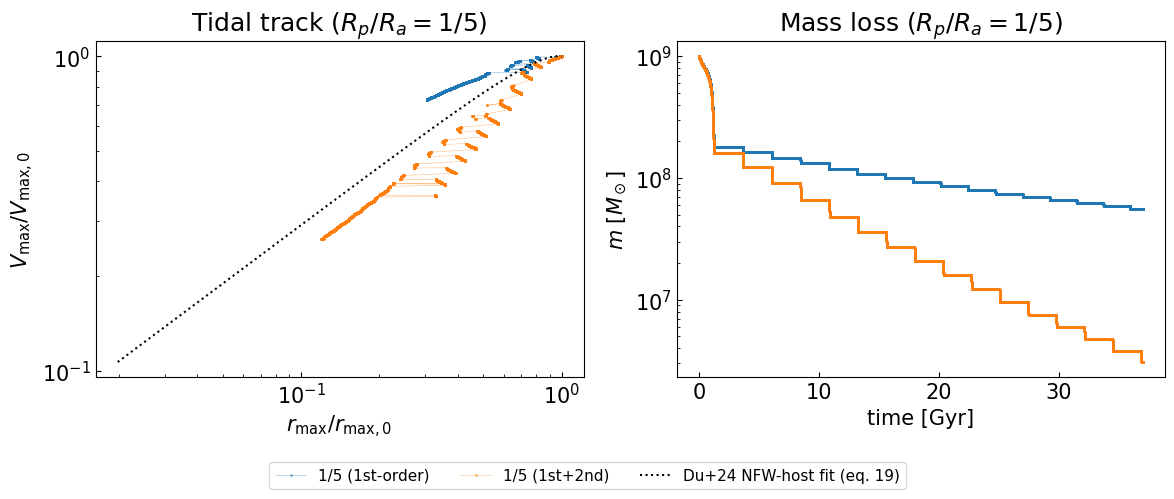

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track([res5_1, res5_2], ax=axes[0], legend=False,
                    title='Tidal track ($R_p/R_a=1/5$)')
sc.plot_mass_loss([res5_1, res5_2], ax=axes[1], legend=False,
                  title='Mass loss ($R_p/R_a=1/5$)')

#---Du+24 eq. 19 fitting curve (NFW subhalo, NFW host)
x_ref = np.logspace(-4, 0, 400)
R_du, V_du = du24_nfw_track(x_ref)
axes[0].plot(R_du, V_du, color='black', linestyle=':', linewidth=1.5,
             label='Du+24 NFW-host fit (eq. 19)', zorder=5)

h, l = axes[0].get_legend_handles_labels()
fig.legend(sc.markers_to_lines(h), l, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=11)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## $R_p/R_a = 1/20$ — artificial disruption

Radial orbit ($r_{\rm peri} \approx 7$ kpc), Du+24's Fig. 10 mass-loss case. The hard cut at $l_t$ destroys the subhalo within the first few pericentres.

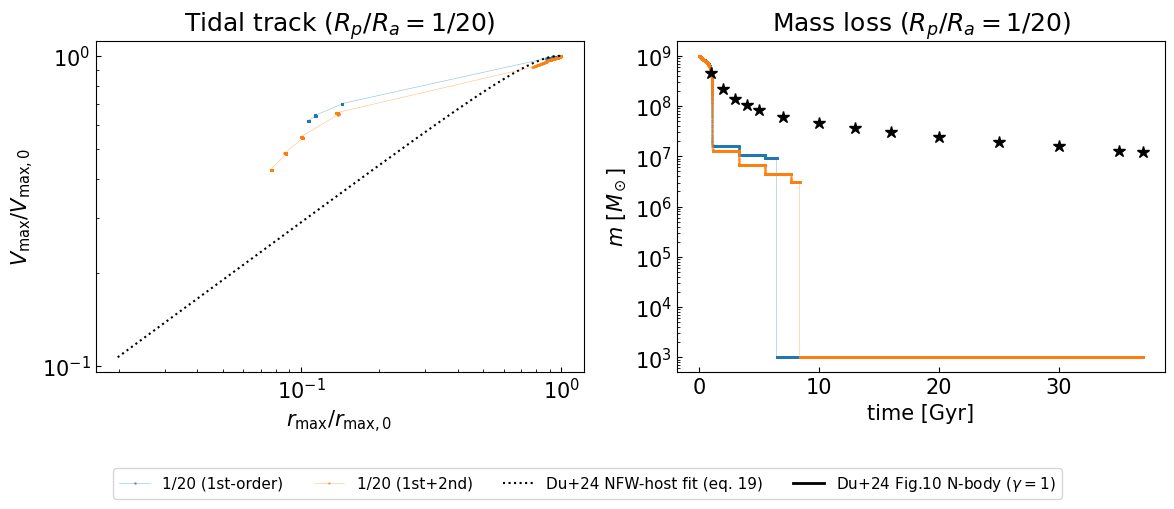

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track([res20_1, res20_2], ax=axes[0], legend=False,
                    title='Tidal track ($R_p/R_a=1/20$)')
sc.plot_mass_loss([res20_1, res20_2], ax=axes[1], legend=False,
                  title='Mass loss ($R_p/R_a=1/20$)')

#---Du+24 eq. 19 fitting curve (NFW subhalo, NFW host)
x_ref = np.logspace(-4, 0, 400)
R_du, V_du = du24_nfw_track(x_ref)
axes[0].plot(R_du, V_du, color='black', linestyle=':', linewidth=1.5,
             label='Du+24 NFW-host fit (eq. 19)', zorder=5)

#---Du+24 Fig. 10 N-body bound mass (gamma=1, Rp/Ra=1/20).
#   Approximate: read by eye off the green circles in their figure.
t_du = np.array([1., 2., 3., 4., 5., 7., 10., 13., 16., 20., 25., 30., 35., 37.])
x_du = np.array([0.45, 0.22, 0.14, 0.105, 0.085, 0.062, 0.046, 0.037,
                 0.030, 0.024, 0.019, 0.016, 0.013, 0.012])
axes[1].plot(t_du, x_du * M_tot_sub, 'k*', ms=9,
             label=r'Du+24 Fig.10 N-body ($\gamma=1$)', zorder=5)

h, l = axes[0].get_legend_handles_labels()
h1, l1 = axes[1].get_legend_handles_labels()
for hh, ll in zip(h1, l1):
    if ll not in l:
        h.append(hh)
        l.append(ll)
fig.legend(sc.markers_to_lines(h), l, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=4, fontsize=11)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## Physics: three regimes and artificial disruption

**$R_p/R_a = 1/5$ — the surviving track.** eq. 19 is an N-body relation in which mass loss *is* the body re-stripping and re-equilibrating — one coupled process. Our pipeline does it as two separate operations: King62 drops the bound fraction $x$ in discrete hard-cut chunks, while `heat_profile` restructures the interior separately. How far the track sits from eq. 19 depends on whether the hard cut has yet reached the shell that sets $R_{\rm max}$:

- **Regime 1 ($x \gtrsim 0.4$):** $l_t$ sits well outside $R_{\rm max}$; only the loosely-bound NFW envelope is stripped. The $V_{\rm max}$-defining shell is untouched pristine NFW, so the track matches eq. 19 ($V_{\rm max}$ within 1%, $R_{\rm max}$ within 5%), curvature included.
- **Regime 2 ($0.05 \lesssim x \lesssim 0.4$):** $l_t$ shrinks to $\sim R_{\rm max}$ and the hard cut bites into the $V_{\rm max}$-defining region. $x$ now outruns the structure — the cut removes mass faster than the interior re-equilibrates — so at a given bound fraction both $R_{\rm max}$ and $V_{\rm max}$ sit above eq. 19 ($V_{\rm max}$ $+$10–20%, $R_{\rm max}$ $+$30–40%).
- **Regime 3 ($x \lesssim 0.05$):** only the first+second-order run reaches here ($x \approx 0.01$); the first-order run stalls near $x \approx 0.15$. $V_{\rm max}$ returns onto eq. 19 — it is now pinned to the deep NFW cusp ($\varepsilon \propto r^2 \to 0$, heating cannot touch it) and eq. 19's $V_{\rm max}$ is cusp-set too. But $R_{\rm max}$ keeps lagging, drifting to $\sim$1.6$\times$ eq. 19. So the deep track *crosses* eq. 19 rather than asymptoting onto it: the $V_{\rm max}$ projection converges, the full 2-D track does not. (`heat_profile` also flags large shell-expansion clamps here — the deep structure is not fully trustworthy.)

**$R_p/R_a = 1/20$ — artificial disruption.** On Du+24's radial orbit the first pericentre hard-cuts the subhalo to a bare stub with no interior $V_{\rm max}$ peak — the tidal track ends after one passage. Within a few more pericentres the King62 tidal radius collapses below the stub and drains it to the mass floor ($t \approx 4$ Gyr). Du+24's N-body strips $\sim$25%/pericentre and survives all $\sim$18 passages: their Kazantzidis-truncated tail keeps an extended outer profile, so the subhalo never becomes a bare stub and $l_t$ never collapses. Removing the hard cut — a Phase-2 exponentially-truncated tail — is what this baseline shows is needed.

In [8]:
#---per-regime deviation from eq. 19 (rmax and Vmax) on the 1/5 orbit;
#   disruption time on the 1/20 orbit
d = np.load(_out)
Mtot = float(d['M_tot_sub'])

def regimes(tag, m, rmax, vmax):
    ok = np.isfinite(vmax) & np.isfinite(rmax) & np.isfinite(m) & (m > 0)
    x = m[ok] / Mtot
    Rdu, Vdu = du24_nfw_track(x)
    rR = (rmax[ok] / d['rmax0']) / Rdu
    rV = (vmax[ok] / d['vmax0']) / Vdu
    print(f"  {tag}: deepest x = {x.min():.4f}")
    for lo, hi, name in [(0.4, 1.01, 'regime 1 (x>0.4)   '),
                         (0.05, 0.4, 'regime 2 (0.05-0.4)'),
                         (0.0, 0.05, 'regime 3 (x<0.05)  ')]:
        s = (x >= lo) & (x < hi)
        if s.any():
            print(f"     {name}: rmax/eq19 = {np.median(rR[s]):.2f}, "
                  f"Vmax/eq19 = {np.median(rV[s]):.2f}")

def disruption(tag, t, m):
    ok = np.isfinite(m) & (m > 0)
    t, m = t[ok], m[ok]
    floored = np.where(m <= cfg.Mres)[0]
    if len(floored):
        print(f"  {tag}: disrupts at t = {t[floored[0]]:.2f} Gyr")
    else:
        print(f"  {tag}: survives, final x = {m[-1]/Mtot:.3e}")

print("Rp/Ra = 1/5  (surviving track, deviation from eq. 19):")
regimes('1st-order', d['m51'], d['rmax51'], d['vmax51'])
regimes('1st+2nd  ', d['m52'], d['rmax52'], d['vmax52'])
print("Rp/Ra = 1/20 (Du+24 mass-loss orbit):")
disruption('1st-order', d['t201'], d['m201'])
disruption('1st+2nd  ', d['t202'], d['m202'])


Rp/Ra = 1/5  (surviving track, deviation from eq. 19):
  1st-order: deepest x = 0.0558
     regime 1 (x>0.4)   : rmax/eq19 = 1.05, Vmax/eq19 = 1.00
     regime 2 (0.05-0.4): rmax/eq19 = 0.92, Vmax/eq19 = 1.13
  1st+2nd  : deepest x = 0.0031
     regime 1 (x>0.4)   : rmax/eq19 = 1.04, Vmax/eq19 = 1.00
     regime 2 (0.05-0.4): rmax/eq19 = 1.45, Vmax/eq19 = 1.08
     regime 3 (x<0.05)  : rmax/eq19 = 1.56, Vmax/eq19 = 0.93
Rp/Ra = 1/20 (Du+24 mass-loss orbit):
  1st-order: disrupts at t = 6.47 Gyr
  1st+2nd  : disrupts at t = 8.39 Gyr


## Profile snapshots

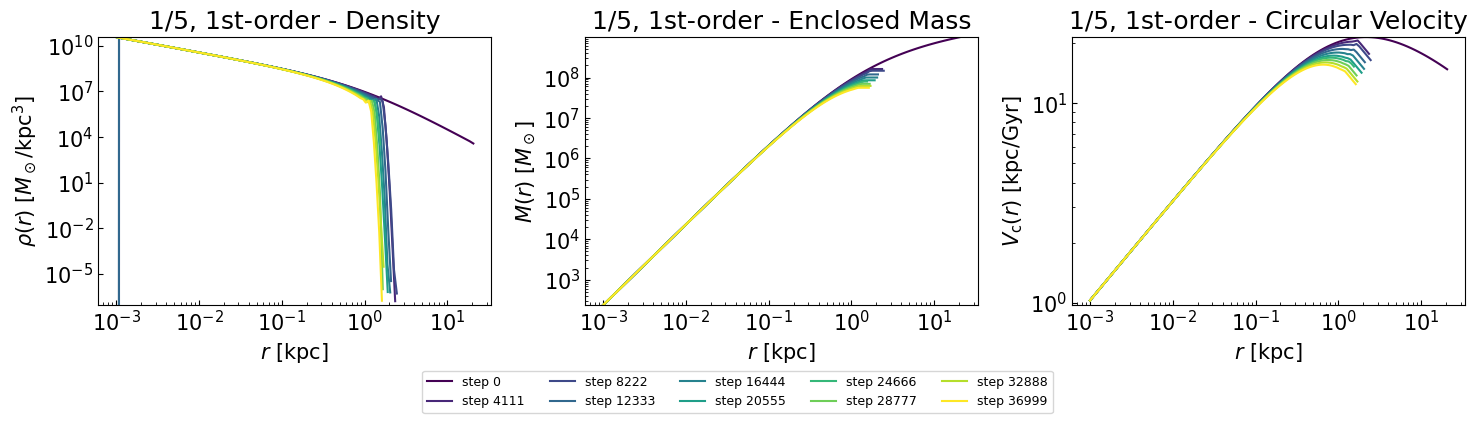

In [9]:
shared = sc.profile_ylims(res5_1, res5_2, res20_1, res20_2)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.plot_profile_snapshots(res5_1, axes=axes, title_prefix='1/5, 1st-order - ', ylims=shared)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()
plt.show()

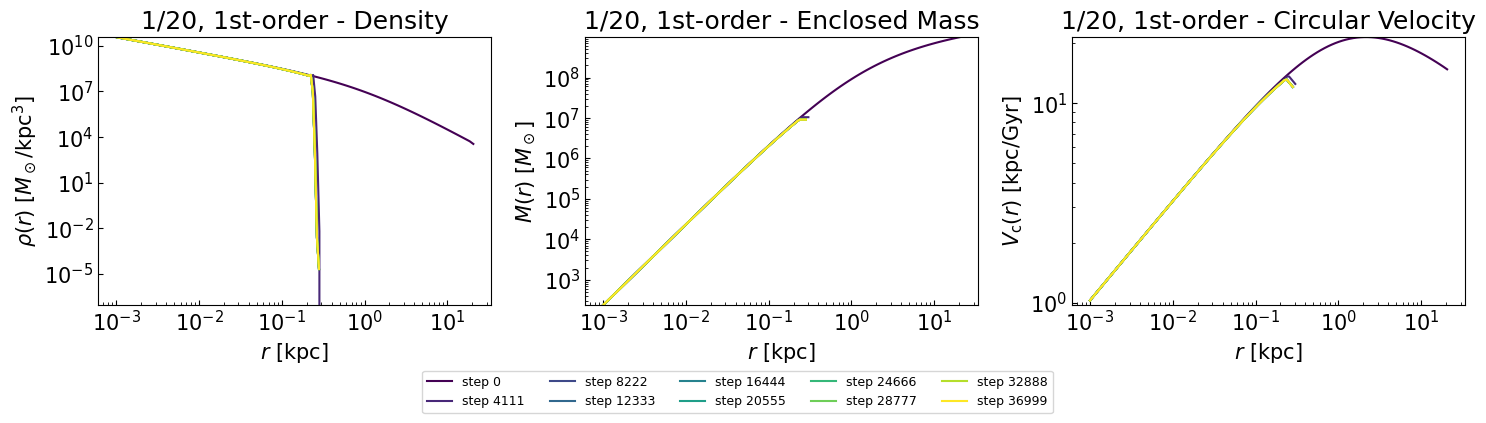

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.plot_profile_snapshots(res20_1, axes=axes, title_prefix='1/20, 1st-order - ', ylims=shared)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()
plt.show()

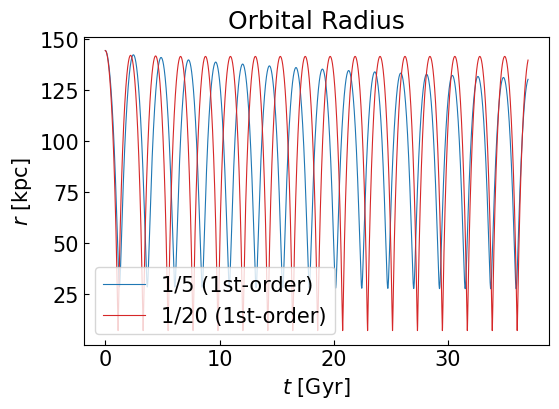

In [11]:
sc.plot_orbit([res5_1, res20_1],
              styles=[dict(color='C0', lw=0.8), dict(color='C3', lw=0.8)])
plt.show()